In [1]:
import matplotlib.pyplot as plt
import torch
import torch_geometric

# from graphMatching import *
from matplotlib.patches import ConnectionPatch
from model_tg import *
from networkx import read_edgelist
from scipy.io import loadmat
from utils import *

/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  import torch_geometric.typing
/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  import torch_geometric.typing
/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: /home/ealva

In [2]:
print(torch_geometric.__version__)

2.7.0


In [3]:
# !pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.1.0+cu121.html
# !pip install torch-geometric

In [4]:
data = "ACM_DBLP" # args.dataset

device = torch.device('cuda:0' if torch.cuda.is_available() else "cpu")
train_features = {}
if (data == "ACM_DBLP"):
	train_set = ["ACM", "DBLP"]
	input_dim = 17
	b = np.load('data/ACM-DBLP.npz')
	train_features["ACM"] = [torch.from_numpy(b["x1"]).float()]
	train_features["DBLP"] = [torch.from_numpy(b["x2"]).float()]
	test_pairs = b['test_pairs'].astype(np.int32)
	NUM_HIDDEN_LAYERS = 12
	HIDDEN_DIM = [1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024]
	output_feature_size = 1024
	lr = 0.0001
	epoch = 100
elif (data == "Douban Online_Offline"):
	a1, f1, a2, f2, test_pairs = load_douban()
	f1 = f1.A
	f2 = f2.A
	train_set = ["Online", "Offline"]
	input_dim = 538
	test_pairs = torch.tensor(np.array(test_pairs, dtype=int)) - 1
	test_pairs = test_pairs.numpy()
	train_features["Online"] = [torch.from_numpy(f1).float()]
	train_features["Offline"] = [torch.from_numpy(f2).float()]
	NUM_HIDDEN_LAYERS = 6
	HIDDEN_DIM = [512,512,512,512,512,512,512]
	output_feature_size = 512
	lr = 0.0001
	epoch = 100

In [5]:
b.files

['edge_index1', 'edge_index2', 'x1', 'x2', 'pos_pairs', 'test_pairs']

In [6]:
b["pos_pairs"]

array([[1177,  607],
       [2799, 8028],
       [3122, 3848],
       ...,
       [ 200, 3360],
       [7605, 5020],
       [6102,  570]], dtype=uint16)

In [7]:
print(train_features["ACM"][0].shape)
train_features["ACM"]

torch.Size([9872, 17])


[tensor([[61., 42., 16.,  ..., 14.,  1., 22.],
         [54., 18., 12.,  ..., 11.,  0., 16.],
         [54., 61.,  9.,  ..., 10.,  0., 39.],
         ...,
         [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  ...,  1.,  0.,  0.],
         [ 0.,  0.,  0.,  ...,  0.,  0.,  1.]])]

In [8]:
train_features

{'ACM': [tensor([[61., 42., 16.,  ..., 14.,  1., 22.],
          [54., 18., 12.,  ..., 11.,  0., 16.],
          [54., 61.,  9.,  ..., 10.,  0., 39.],
          ...,
          [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  ...,  1.,  0.,  0.],
          [ 0.,  0.,  0.,  ...,  0.,  0.,  1.]])],
 'DBLP': [tensor([[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 4., 1.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 1., 0., 0.]])]}

In [9]:
train_features["ACM"][0]

tensor([[61., 42., 16.,  ..., 14.,  1., 22.],
        [54., 18., 12.,  ..., 11.,  0., 16.],
        [54., 61.,  9.,  ..., 10.,  0., 39.],
        ...,
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  1.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  1.]])

In [10]:
train_features[train_set[0]][0]

tensor([[61., 42., 16.,  ..., 14.,  1., 22.],
        [54., 18., 12.,  ..., 11.,  0., 16.],
        [54., 61.,  9.,  ..., 10.,  0., 39.],
        ...,
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  1.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  1.]])

In [11]:
train_features["DBLP"][0]

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 4., 1.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 1., 0., 0.]])

In [12]:
train_features[train_set[1]][0]

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 4., 1.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 1., 0., 0.]])

In [13]:
""" temp = torch.from_numpy(b["x1"]).float() # G1, features
print(temp.shape)
temp """

' temp = torch.from_numpy(b["x1"]).float() # G1, features\nprint(temp.shape)\ntemp '

In [14]:
""" temp = torch.from_numpy(b["x2"]).float() # G2, features
print(temp.shape)
temp """

' temp = torch.from_numpy(b["x2"]).float() # G2, features\nprint(temp.shape)\ntemp '

In [15]:
""" temp = b["test_pairs"]
print(temp.shape)
temp """

' temp = b["test_pairs"]\nprint(temp.shape)\ntemp '

In [16]:
test_pairs

array([[   0, 6829],
       [   2, 3102],
       [   3, 3584],
       ...,
       [9841, 3392],
       [9850,  306],
       [9868, 9011]], dtype=int32)

In [17]:
train_set

['ACM', 'DBLP']

In [18]:
print("Loading training datasets")

train_loader = {}
for dataset in train_set:
	train_loader[dataset] = [load_adj(dataset)]


Loading training datasets


/home/ealvarez/Project/Graph_MatchingAlignment/Network-Alignment-with-Transferable-Graph-Autoencoders/utils.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  S = torch.lo

In [19]:
train_loader.keys()

dict_keys(['ACM', 'DBLP'])

In [20]:
train_loader

{'ACM': [tensor([[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 0., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]])],
 'DBLP': [tensor([[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]])]}

---

In [21]:
adj_tensor = train_loader["ACM"][0]
print(adj_tensor.shape)
adj_tensor

torch.Size([9872, 9872])


tensor([[0., 1., 1.,  ..., 0., 0., 0.],
        [1., 0., 1.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [22]:
adj = coo_matrix(adj_tensor.numpy())
print(adj.shape)
adj

(9872, 9872)


<9872x9872 sparse matrix of type '<class 'numpy.float32'>'
	with 79122 stored elements in COOrdinate format>

In [23]:
adj_norm = preprocess_graph(adj)
print(len(adj_norm))
adj_norm

3


(array([[   0,    0],
        [   1,    0],
        [   2,    0],
        ...,
        [9870, 9870],
        [4454, 9871],
        [9871, 9871]], dtype=int32),
 array([0.0049505 , 0.00538054, 0.00612403, ..., 0.2       , 0.5       ,
        0.5       ]),
 (9872, 9872))

In [24]:
adj_norm[0]

array([[   0,    0],
       [   1,    0],
       [   2,    0],
       ...,
       [9870, 9870],
       [4454, 9871],
       [9871, 9871]], dtype=int32)

In [25]:
adj_norm[1]

array([0.0049505 , 0.00538054, 0.00612403, ..., 0.2       , 0.5       ,
       0.5       ])

In [26]:
adj_norm[2]

(9872, 9872)

In [27]:
adj_norm = torch.sparse.FloatTensor(torch.LongTensor(adj_norm[0].T),
									torch.FloatTensor(adj_norm[1]),
									torch.Size(adj_norm[2])).to(device)
print(adj_norm.shape)
adj_norm

torch.Size([9872, 9872])


/tmp/ipykernel_1378574/1719744203.py:1: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /opt/conda/conda-bld/pytorch_1720538438429/work/torch/csrc/utils/tensor_new.cpp:641.)
  adj_norm = torch.sparse.FloatTensor(torch.LongTensor(adj_norm[0].T),


tensor(indices=tensor([[   0,    1,    2,  ..., 9870, 4454, 9871],
                       [   0,    0,    0,  ..., 9870, 9871, 9871]]),
       values=tensor([0.0050, 0.0054, 0.0061,  ..., 0.2000, 0.5000, 0.5000]),
       device='cuda:0', size=(9872, 9872), nnz=88994, layout=torch.sparse_coo)

In [28]:
type(adj_norm)

torch.Tensor

In [29]:
adj_norm

tensor(indices=tensor([[   0,    1,    2,  ..., 9870, 4454, 9871],
                       [   0,    0,    0,  ..., 9870, 9871, 9871]]),
       values=tensor([0.0050, 0.0054, 0.0061,  ..., 0.2000, 0.5000, 0.5000]),
       device='cuda:0', size=(9872, 9872), nnz=88994, layout=torch.sparse_coo)

In [30]:
# Transform data

adj_coo = adj_norm.coalesce()  # Asegurar formato COO
edge_index = adj_coo.indices() # [2, E]
edge_weight = adj_coo.values().view(-1, 1) # Fron [E] to [E,1]
edge_attr = torch.cat([
	edge_weight.abs(),         # strength
	torch.sign(edge_weight),   # direction (+1, -1)
	edge_weight ** 2           # nonlinearity
], dim=1)            # [E,3]

features = train_features["ACM"][0]
print(edge_index.shape)
print(edge_index)

print(edge_weight.shape)
print(edge_weight)

print(edge_attr.shape)
print(edge_attr)

print(features.shape)
print(features)

torch.Size([2, 88994])
tensor([[   0,    0,    0,  ..., 9870, 9871, 9871],
        [   0,    1,    2,  ..., 9870, 4454, 9871]], device='cuda:0')
torch.Size([88994, 1])
tensor([[0.0050],
        [0.0054],
        [0.0061],
        ...,
        [0.2000],
        [0.5000],
        [0.5000]], device='cuda:0')
torch.Size([88994, 3])
tensor([[4.9505e-03, 1.0000e+00, 2.4507e-05],
        [5.3805e-03, 1.0000e+00, 2.8950e-05],
        [6.1240e-03, 1.0000e+00, 3.7504e-05],
        ...,
        [2.0000e-01, 1.0000e+00, 4.0000e-02],
        [5.0000e-01, 1.0000e+00, 2.5000e-01],
        [5.0000e-01, 1.0000e+00, 2.5000e-01]], device='cuda:0')
torch.Size([9872, 17])
tensor([[61., 42., 16.,  ..., 14.,  1., 22.],
        [54., 18., 12.,  ..., 11.,  0., 16.],
        [54., 61.,  9.,  ..., 10.,  0., 39.],
        ...,
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  1.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  1.]])


In [31]:
# Remove this
"""
# reduce dimensions of node features
for item in train_features:
	feat = train_features[item][0]
	reduced_feat = feat[:, :3]  # Reduce to first 'input_dim' dimensions
	train_features[item][0] = reduced_feat
train_features """

"\n# reduce dimensions of node features\nfor item in train_features:\n\tfeat = train_features[item][0]\n\treduced_feat = feat[:, :3]  # Reduce to first 'input_dim' dimensions\n\ttrain_features[item][0] = reduced_feat\ntrain_features "

In [32]:
# Remove this
# PCA

"""
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

for item in train_features:
	feat = train_features[item][0]

	scaler = StandardScaler()
	X_scaled = scaler.fit_transform(feat)

	pca = PCA(n_components=3)
	X_pca = pca.fit_transform(X_scaled)

	train_features[item][0] = torch.from_numpy(X_pca).float()
train_features """

'\nfrom sklearn.decomposition import PCA\nfrom sklearn.preprocessing import StandardScaler\n\nfor item in train_features:\n\tfeat = train_features[item][0]\n\n\tscaler = StandardScaler()\n\tX_scaled = scaler.fit_transform(feat)\n\n\tpca = PCA(n_components=3)\n\tX_pca = pca.fit_transform(X_scaled)\n\n\ttrain_features[item][0] = torch.from_numpy(X_pca).float()\ntrain_features '

---

In [33]:
""" temp = train_loader["ACM"][0]
print(temp.shape)
temp """

' temp = train_loader["ACM"][0]\nprint(temp.shape)\ntemp '

In [34]:
""" temp = train_loader["DBLP"][0]
print(temp.shape)
temp """

' temp = train_loader["DBLP"][0]\nprint(temp.shape)\ntemp '

In [35]:
train_loader

{'ACM': [tensor([[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 0., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]])],
 'DBLP': [tensor([[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]])]}

In [36]:
train_set

['ACM', 'DBLP']

In [37]:
# Init

encoder = "GINE" # Change GIN, GINE
epoch = 100 # remove
output_feature_size = 3 # remove
flag = True # remove

if encoder == "GIN":
	input_dim = 17
	GAE = TGAE_GIN(NUM_HIDDEN_LAYERS,
				input_dim,
				HIDDEN_DIM,
				output_feature_size).to(device)
elif encoder == "GINE":
	input_dim = 17 # Change 3

	""" for item in train_features:
		feat = train_features[item][0]
		reduced_feat = feat[:, :3]  # Reduce to first 'input_dim' dimensions
		train_features[item][0] = reduced_feat """

	GAE = TGAE_GINE(NUM_HIDDEN_LAYERS,
			input_dim,
			HIDDEN_DIM,
			output_feature_size).to(device)

In [38]:
print("Generating training features")
print("Fitting model", encoder)
# fit_TGAE_subgraph(data, len(train_set) * (1 + 1), model, epoch, train_loader, train_features, device, lr,test_pairs)

# ---
no_samples = len(train_set) * (1 + 1)
# GAE = model
# ---

best_hitAtOne = 0
best_hitAtFive = 0
best_hitAtTen = 0
best_hitAtFifty = 0

optimizer = Adam(GAE.parameters(), lr=lr,weight_decay=5e-4)

loop_obj = tqdm(range(1, epoch + 1))
for step in loop_obj:
	loop_obj.set_description(f"Epoch: {step}")
	
	loss = 0
	
	for dataset in train_loader.keys():
		S = train_loader[dataset][0]
		initial_features = train_features[dataset]
		
		for i in range(len(train_loader[dataset])):
			adj_tensor = train_loader[dataset][i]
			adj = coo_matrix(adj_tensor.numpy())
			adj_norm = preprocess_graph(adj)
			pos_weight = float(adj.shape[0] * adj.shape[0] - adj.sum()) / adj.sum()
			norm = adj.shape[0] * adj.shape[0] / float((adj.shape[0] * adj.shape[0] - adj.sum()) * 2)

			adj_label = coo_matrix(S.numpy())
			adj_label = sparse_to_tuple(adj_label)

			adj_norm = torch.sparse.FloatTensor(torch.LongTensor(adj_norm[0].T),
												torch.FloatTensor(adj_norm[1]),
												torch.Size(adj_norm[2])).to(device)
			adj_label = torch.sparse.FloatTensor(torch.LongTensor(adj_label[0].T),
												torch.FloatTensor(adj_label[1]),
												torch.Size(adj_label[2])).to(device)

			initial_feature = initial_features[i].to(device)

			weight_mask = adj_label.to_dense().view(-1) == 1
			weight_tensor = torch.ones(weight_mask.size(0))
			weight_tensor[weight_mask] = pos_weight
			weight_tensor = weight_tensor.to(device)
			
			# Transform data
			# This seccion is modified to adapt to the new GAE implementation
			adj_coo = adj_norm.coalesce()  # Asegurar formato COO
			edge_index = adj_coo.indices().long() # [2, E]
			edge_weight = adj_coo.values().float().view(-1, 1) # [E,1]
			edge_attr = torch.cat([
				edge_weight.abs(),         # strength
				torch.sign(edge_weight),   # direction (+1, -1)
				edge_weight ** 2           # nonlinearity
			], dim=1) # [E,3]

			if flag: # Show data shapes only once
				print(edge_index.shape)
				print(edge_index)
				print()
				print(edge_weight.shape)
				print(edge_weight)
				print()
				print(edge_attr.shape)
				print(edge_attr)
				print()
				print(initial_feature.shape)
				print(initial_feature)
				flag = False

			if encoder == "GIN":
				z = GAE(initial_feature, edge_index)
			elif encoder == "GINE":
				z = GAE(initial_feature, edge_index, edge_weight)

			# z = GAE(initial_feature, adj_norm)
			A_pred = torch.sigmoid(torch.matmul(z, z.t()))
			loss += norm * F.binary_cross_entropy(A_pred.view(-1), adj_label.to_dense().view(-1),
														weight=weight_tensor)
			# loop_obj.set_postfix_str(f"Loss: {loss:.4f}")
	
	optimizer.zero_grad()
	loss = loss / no_samples
	loss.backward()
	optimizer.step()

	loop_obj.set_postfix_str(f"Loss: {loss:.4f}")

	# ---
	keys = list(train_loader.keys())
	S1 = train_loader[keys[0]][0]
	S2 = train_loader[keys[1]][0]
	
	adj_S1 = coo_matrix(S1.numpy())
	adj_norm_1 = preprocess_graph(adj_S1)
	adj_norm_1 = torch.sparse.FloatTensor(torch.LongTensor(adj_norm_1[0].T),
											torch.FloatTensor(adj_norm_1[1]),
											torch.Size(adj_norm_1[2])).to(device)
	adj_S2 = coo_matrix(S2.numpy())
	adj_norm_2 = preprocess_graph(adj_S2)
	adj_norm_2 = torch.sparse.FloatTensor(torch.LongTensor(adj_norm_2[0].T),
											torch.FloatTensor(adj_norm_2[1]),
											torch.Size(adj_norm_2[2])).to(device)
	""" if (data == "ACM_DBLP"):
		S1_feat = train_features["ACM"][0]
		S2_feat = train_features["DBLP"][0]
	elif (data == "Douban Online_Offline"):
		S1_feat = train_features["Online"][0]
		S2_feat = train_features["Offline"][0] """

	S1_feat = train_features[train_set[0]][0]
	S2_feat = train_features[train_set[1]][0]

	# ---
	adj_coo1 = adj_norm_1.coalesce()
	edge_index1 = adj_coo1.indices().long()
	edge_weight1 = adj_coo1.values().float().view(-1, 1)
	edge_attr1 = torch.cat([
		edge_weight1.abs(),         # strength
		torch.sign(edge_weight1),   # direction (+1, -1)
		edge_weight1 ** 2           # nonlinearity
	], dim=1) # [E,3]


	adj_coo2 = adj_norm_2.coalesce()
	edge_index2 = adj_coo2.indices().long()
	edge_weight2 = adj_coo2.values().float().view(-1, 1) # [E, 1] Change
	edge_attr2 = torch.cat([
		edge_weight2.abs(),         # strength
		torch.sign(edge_weight2),   # direction (+1, -1)
		edge_weight2 ** 2           # nonlinearity
	], dim=1) # [E,3]
	# ---

	# ---
	if encoder == "GIN":
		S1_emb = GAE(S1_feat.to(device), edge_index1).detach() # adj_norm_1).detach()
		S2_emb = GAE(S2_feat.to(device), edge_index2).detach() # adj_norm_2).detach()
	elif encoder == "GINE":
		S1_emb = GAE(S1_feat.to(device), edge_index1, edge_weight1).detach() # adj_norm_1).detach()
		S2_emb = GAE(S2_feat.to(device), edge_index2, edge_weight2).detach() # adj_norm_2).detach()

	D = torch.cdist(S1_emb, S2_emb, 2) # Euclidean distance
	
	if (data == "ACM_DBLP"):
		test_idx = test_pairs[:, 0].astype(np.int32)
		labels = test_pairs[:, 1].astype(np.int32)
	elif (data == "Douban Online_Offline"):
		test_idx = test_pairs[0, :].astype(np.int32)
		labels = test_pairs[1, :].astype(np.int32)
	
	hitAtOne = 0
	hitAtFive = 0
	hitAtTen = 0
	hitAtFifty = 0
	hitAtHundred = 0
	
	# test
	for i in range(len(test_idx)):
		dist_list = D[test_idx[i]]
		# print(i, test_idx[i], dist_list)
		sorted_neighbors = torch.argsort(dist_list).cpu()
		label = labels[i]
		
		""" if i == 0:
			print(label, sorted_neighbors[0].item(), sorted_neighbors)
			# 6829 6829 tensor([6829, 3102,  601,  ..., 7878, 9701, 2044]) """
		
		for j in range(100):
			if (sorted_neighbors[j].item() == label):
				if (j == 0):
					hitAtOne += 1
					hitAtFive += 1
					hitAtTen += 1
					hitAtFifty += 1
					hitAtHundred += 1
					break
				elif (j <= 4):
					hitAtFive += 1
					hitAtTen += 1
					hitAtFifty += 1
					hitAtHundred += 1
					break
				elif (j <= 9):
					hitAtTen += 1
					hitAtFifty += 1
					hitAtHundred += 1
					break
				elif (j <= 49):
					hitAtFifty += 1
					hitAtHundred += 1
					break
				elif (j <= 100):
					hitAtHundred += 1
					break
	
	cur_hitAtOne = hitAtOne / len(test_idx)
	cur_hitAtFive = hitAtFive / len(test_idx)
	cur_hitAtTen = hitAtTen / len(test_idx)
	cur_hitAtFifty = hitAtFifty / len(test_idx)

	if(cur_hitAtOne > best_hitAtOne): best_hitAtOne = cur_hitAtOne
	if (cur_hitAtFive > best_hitAtFive): best_hitAtFive = cur_hitAtFive
	if (cur_hitAtTen > best_hitAtTen): best_hitAtTen = cur_hitAtTen
	if (cur_hitAtFifty > best_hitAtFifty): best_hitAtFifty = cur_hitAtFifty


print("The best results achieved:")
print("Hit@1: ", end="")
print(best_hitAtOne)
print("Hit@5: ", end="")
print(best_hitAtFive)
print("Hit@10: ", end="")
print(best_hitAtTen)
print("Hit@50: ", end="")
print(best_hitAtFifty)

Generating training features
Fitting model GINE


Epoch: 1:   0%|          | 0/100 [00:00<?, ?it/s]

torch.Size([2, 88994])
tensor([[   0,    0,    0,  ..., 9870, 9871, 9871],
        [   0,    1,    2,  ..., 9870, 4454, 9871]], device='cuda:0')

torch.Size([88994, 1])
tensor([[0.0050],
        [0.0054],
        [0.0061],
        ...,
        [0.2000],
        [0.5000],
        [0.5000]], device='cuda:0')

torch.Size([88994, 3])
tensor([[4.9505e-03, 1.0000e+00, 2.4507e-05],
        [5.3805e-03, 1.0000e+00, 2.8950e-05],
        [6.1240e-03, 1.0000e+00, 3.7504e-05],
        ...,
        [2.0000e-01, 1.0000e+00, 4.0000e-02],
        [5.0000e-01, 1.0000e+00, 2.5000e-01],
        [5.0000e-01, 1.0000e+00, 2.5000e-01]], device='cuda:0')

torch.Size([9872, 17])
tensor([[61., 42., 16.,  ..., 14.,  1., 22.],
        [54., 18., 12.,  ..., 11.,  0., 16.],
        [54., 61.,  9.,  ..., 10.,  0., 39.],
        ...,
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  1.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  1.]], device='cuda:0')


Epoch: 100: 100%|██████████| 100/100 [07:16<00:00,  4.36s/it, Loss: 0.2545]

The best results achieved:
Hit@1: 0.3239130434782609
Hit@5: 0.5760869565217391
Hit@10: 0.6575098814229249
Hit@50: 0.7891304347826087


In [39]:
# Get embeddings

print(S1_emb.shape)
S1_emb

torch.Size([9872, 3])


tensor([[-5.6134, -0.6238,  3.7549],
        [-3.5028, -0.2477,  3.5957],
        [-6.2037, -0.5738,  3.8351],
        ...,
        [-1.0508,  0.0604, -0.1019],
        [ 0.4340, -0.1445,  0.4972],
        [ 0.0420,  0.1539,  0.2680]], device='cuda:0')

In [40]:
print(S2_emb.shape)
S2_emb

torch.Size([9916, 3])


tensor([[-0.2210,  0.7460,  0.4633],
        [ 0.3367, -0.2737,  0.5990],
        [-0.7313,  0.8025, -0.6999],
        ...,
        [-0.1715,  1.3020, -0.0128],
        [ 1.2005, -0.3416, -0.2566],
        [ 0.7619, -0.2547,  0.2507]], device='cuda:0')

In [54]:
# concat
S_emb_cat = torch.cat((S1_emb, S2_emb), dim=0).cpu().numpy()
S_emb_cat

array([[-5.613409  , -0.6237853 ,  3.7549295 ],
       [-3.5028398 , -0.24773428,  3.595665  ],
       [-6.203714  , -0.5737536 ,  3.8350835 ],
       ...,
       [-0.17148542,  1.3020452 , -0.01279517],
       [ 1.2005373 , -0.34163237, -0.2566192 ],
       [ 0.7619117 , -0.25465658,  0.25068563]], dtype=float32)

##### Similarity analysis (KNN)

In [55]:
# Calculate distance matrix (KNN)
from sklearn.neighbors import NearestNeighbors
import pandas as pd

k = 1

df_y = S2_emb.cpu().numpy()
df_x = S1_emb.cpu().numpy()

knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
knn.fit(df_y)
distances, indices = knn.kneighbors(df_x)
# print(indices)

result = []
for row in indices:
	# df_y_ = df_y.loc[row]
	result.append(row[0])
result

df_match = pd.DataFrame()
df_match["id"] = range(df_x.shape[0])
df_match

# aux = indices[:, top].flatten() # change
# df_y_ = df_y.loc[aux]
df_match["ids"] = result
df_match

,id,ids
0,0,6829
1,1,601
2,2,3102
3,3,3584
4,4,3744
...,...,...
9867,9867,1537
9868,9868,9011
9869,9869,7586
9870,9870,2723


In [56]:
test_pairs

array([[   0, 6829],
       [   2, 3102],
       [   3, 3584],
       ...,
       [9841, 3392],
       [9850,  306],
       [9868, 9011]], dtype=int32)

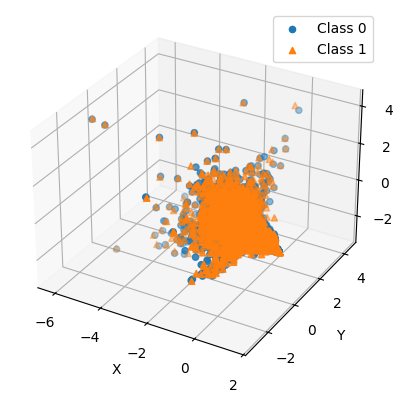

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Datos de ejemplo
X = S_emb_cat[:, 0]
Y = S_emb_cat[:, 1]
Z = S_emb_cat[:, 2]
labels = np.array([0] * S1_emb.shape[0] + [1] * S2_emb.shape[0])  # labels

fig = plt.figure()
ax = fig.add_subplot(projection="3d")

# Separar clases
ax.scatter(X[labels == 0], Y[labels == 0], Z[labels == 0], label="Class 0", marker="o")
ax.scatter(X[labels == 1], Y[labels == 1], Z[labels == 1], label="Class 1", marker="^")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.show()

##### Similarity analysis (Hungarian)

In [ ]:
print(D.shape)
D

Truth

In [ ]:
print(data)
print(test_pairs.shape)
print(test_pairs)

In [ ]:
if (data == "ACM_DBLP"):
	test_pairs_ = test_pairs
elif (data == "Douban Online_Offline"):
	test_pairs_ = test_pairs.T
	
truth = test_pairs_[test_pairs_[:, 1].argsort()]
print(truth.shape)
truth

In [ ]:
truth_ = test_pairs_[test_pairs_[:, 0].argsort()]
print(truth_.shape)
truth_

#### Option 0

In [ ]:
def hungarian(D):
	print("0")
	P = torch.zeros_like(D)
	matrix = D.tolist()
	m = Munkres()
	print("1")
	indexes = m.compute(matrix)
	print("2")
	total = 0
	for r, c in tqdm(indexes):
		print(r)
		P[r][c] = 1
		total += matrix[r][c]
	return P.t()

X = hungarian(D)
print(X.shape)
# online_offline: 215m
# acm_dblp: 2112m
X

In [ ]:
# save

X = X.cpu().numpy()
np.save("P_hungarian_ACM_DBLP", X)

In [ ]:
# load

X = np.load("P_hungarian.npy")
X

In [ ]:
option0 = []
m, n = X.shape
for i in range(m):
	for j in range(n):
		if X[i][j] == 1:
			option0.append([j, i]) # S, S_hat
option0 = np.array(option0)
print(len(option0))
option0

In [ ]:
matching = test_matching(truth, option0)
print(len(matching))
print(len(matching) / len(truth))
matching

#### Option 1

In [ ]:
total_cost, assignments = hungarian_algorithm(D.cpu())

In [ ]:
option1 = np.array(assignments)
option1 = option1[option1[:, 1].argsort()]
print(option1.shape)
option1

In [ ]:
option1_ = option1[:, [1, 0]]
option1_

In [ ]:
matching = test_match(truth, option1)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)

plot_match(G1, G2, matching)

#### Option 2

In [ ]:
import pygmtools as pygm

X = pygm.hungarian(D.cpu().numpy())
print(X.shape)
X

In [ ]:
option2 = matrix_to_edge(X)
option2

In [ ]:
option2_ = option2[:, [1, 0]]
option2_

In [ ]:
matching = test_match(truth, option2)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching)

#### Option 3

In [ ]:
indices = []
for i in range(D.shape[0]):
	dist_list = D[i]
	sorted_neighbors = torch.argsort(dist_list).cpu()
	indices.append([i, sorted_neighbors[0]])

option3 = np.array(indices)
option3 = option3[option3[:, 1].argsort()]
print(option3.shape)
option3

In [ ]:
option3_ = option3[:, [1, 0]]
option3_

In [ ]:
matching = test_match(truth, option3)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching)

#### Option 4

In [ ]:
X = greedy_match(D)
X = X.todense()
X = np.array(X)
print(X.shape)
print(X)

In [ ]:
option4 = matrix_to_edge(X)
option4

In [ ]:
option4_ = option4[:, [1, 0]]
option4_

In [ ]:
matching = test_match(truth, option4)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching)

#### Option 5

In [ ]:
D_ = complete_to_square(D.cpu(), pad_value=100.0)
print(D_.shape)
D_

In [ ]:
D.shape

In [ ]:
# X = get_match(torch.tensor(D_), device)
X = get_match(D, device)
print(X.shape)
X

In [ ]:
option5 = matrix_to_edge(X)
option5

In [ ]:
option5_ = option5[:, [1, 0]]
option5_

In [ ]:
matching = test_match(truth, option5_) # ACM_DBLP (option5_)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching)

---

In [ ]:
a = torch.tensor([[0.0,  0.0], [0.0, 1.0], [0.0,  2.0]])
print(a)
b = torch.tensor([[0.0, 1.0 ], [1.0,  1.0]])
print(b)
torch.cdist(a, b, p=2)

In [ ]:
a = torch.tensor([[4.01, 3.0, 2.0, 0.1, 4.0]])
print(a)
torch.argsort(a, dim=1)

In [ ]:
a = np.array([[9, 2, 3],
			  [4, 5, 6],
			  [7, 0, 5]])

a[a[:, 2].argsort()]